# SeaHub effective pixel-scale analysis from 2D mask area

**Question.** Can stage-matched control embryos constrain the unknown SeaHub
pixel calibration well enough to explain the surface-area QC failures?

**Executive answer.** Yes, as a rough *effective biological calibration*, but
not as physical metrology and not as one global number. The strict-WT
comparison implies approximately **4.25 µm/px at 12–24 hpf**, **6.90 µm/px at
36 hpf**, and **7.56 µm/px at 48–96 hpf** (stage-balanced regime medians).
The early/late split is about 1.8-fold. This is consistent with capture-scale
or magnification changes across source images. A single global SeaHub
calibration is therefore not defensible.

This notebook is analysis-only. It reads the quarantined July 30 products and
does not alter active pipeline outputs or pipeline code.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "20260723_seahub":
    NOTEBOOK_DIR = Path("results/nlammers/20260723_seahub").resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

from seahub_surface_area_calibration import run_analysis

results = run_analysis()
print(
    f"Loaded {len(results['rows']):,} mask/stage comparison rows from "
    f"{results['rows']['experiment_id'].nunique()} completed or partial shards."
)
print(
    f"Calibration cohort: {results['selected_controls']['well_id'].nunique():,} "
    f"reference-like controls, {results['selected_controls']['calibration_fov_id'].nunique()} "
    f"source FOVs, {results['selected_controls']['predicted_stage_hpf'].nunique()} stages."
)

Loaded 2,235 mask/stage comparison rows from 23 completed or partial shards.
Calibration cohort: 376 reference-like controls, 47 source FOVs, 9 stages.


## 1. Preferred strict-WT estimates

Each source crop is intended to contain one embryo. Where the downstream
segmenter produced multiple masks, the analysis uses the largest mask for that
intended well. It then takes a median across the eight embryos in each source
FOV and a median across FOVs, avoiding eightfold pseudoreplication.

The confidence intervals resample source FOV medians. At 12 and 15 hpf only
one control FOV is available, so those intervals resample embryos within that
single FOV and should be treated as especially weak.

In [2]:
stage = results["stage_summary"].copy()
display(
    stage[[
        "stage_hpf", "n_embryos", "n_fovs",
        "strict_wt_effective_um_per_px",
        "strict_wt_bootstrap_ci95_low", "strict_wt_bootstrap_ci95_high",
        "strict_wt_reference_n",
        "legacy_curve_effective_um_per_px",
    ]].round(3).style.format({
        "stage_hpf": "{:.0f}",
        "strict_wt_effective_um_per_px": "{:.3f}",
        "strict_wt_bootstrap_ci95_low": "{:.3f}",
        "strict_wt_bootstrap_ci95_high": "{:.3f}",
        "legacy_curve_effective_um_per_px": "{:.3f}",
    })
)

display(results["regime_summary"].round(3))

,stage_hpf,n_embryos,n_fovs,strict_wt_effective_um_per_px,strict_wt_bootstrap_ci95_low,strict_wt_bootstrap_ci95_high,strict_wt_reference_n,legacy_curve_effective_um_per_px
0,12,8,1,5.687,5.559,6.123,181,5.658
1,14,24,3,4.250,3.604,5.701,203,4.363
2,15,8,1,4.010,3.877,4.038,273,4.024
3,18,32,4,4.060,3.880,4.976,289,3.947
4,24,56,7,4.630,4.320,5.207,301,4.366
5,36,24,3,6.897,5.940,6.917,285,6.937
6,48,64,8,7.557,7.326,8.121,118,7.963
7,72,88,11,7.471,7.174,7.962,21,8.218
8,96,72,9,7.776,6.945,7.994,5,8.277


,capture_regime,stage_range_hpf,n_stages,n_fovs,n_embryos,strict_wt_stage_balanced_um_per_px,strict_wt_stage_min_um_per_px,strict_wt_stage_max_um_per_px,legacy_curve_stage_balanced_um_per_px
0,early (12-24 hpf),12-24,5,16,128,4.250,4.010,5.687,4.363
1,transition (36 hpf),36-36,1,3,24,6.897,6.897,6.897,6.937
2,late (48-96 hpf),48-96,3,28,224,7.557,7.471,7.776,8.218


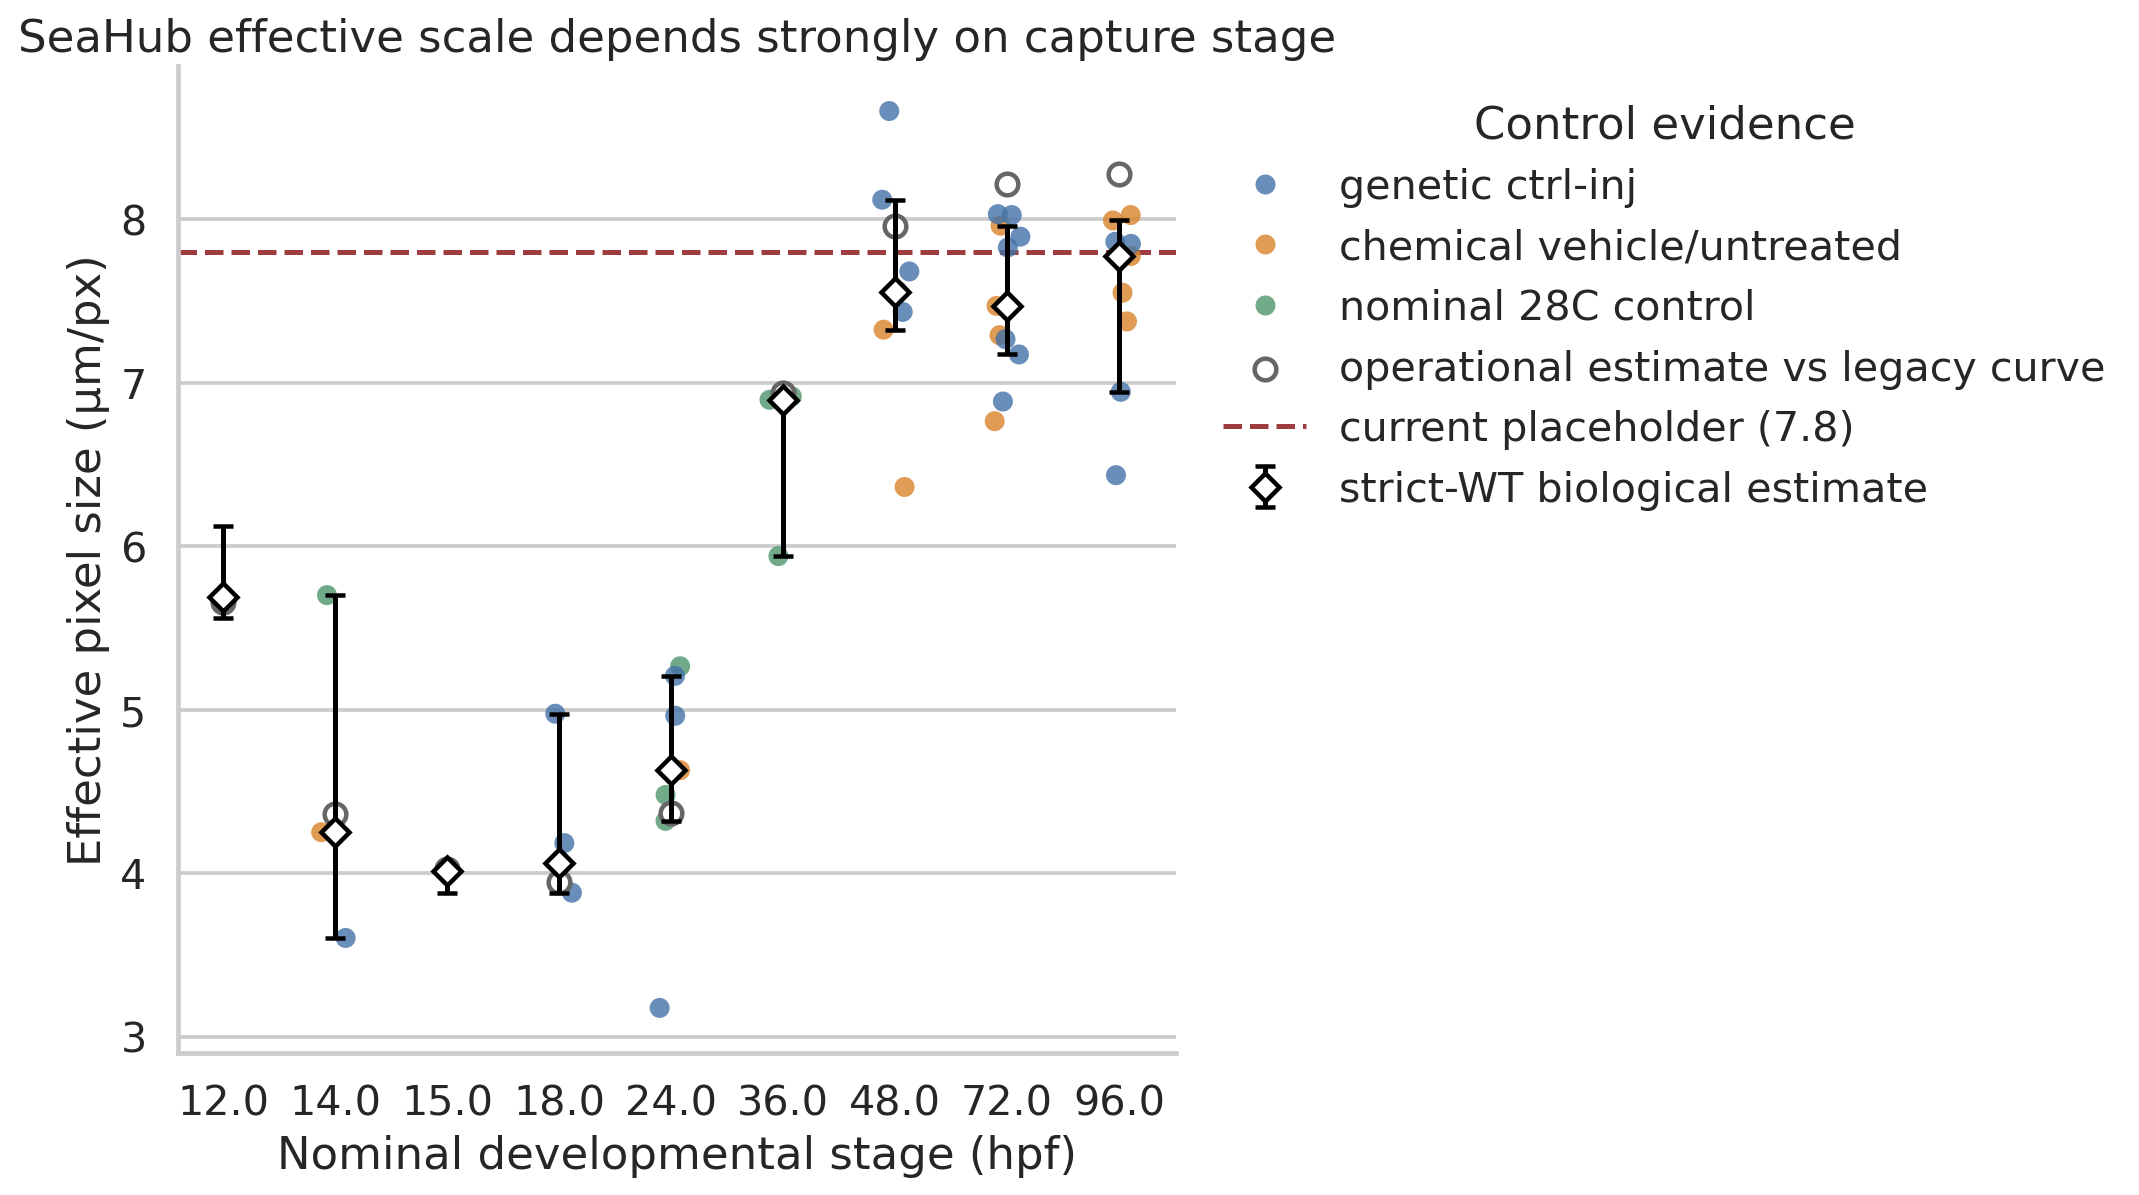

In [3]:
display(Image(filename=str(results["figure_paths"]["effective_scale"])))

The colored dots are source-FOV estimates against the strict-WT stage median;
black diamonds are the stage recommendations. Open gray circles show the
corresponding answer against the packaged legacy QC curve. The dashed line is
the current 7.8 µm/px placeholder.

Late-stage estimates are near the placeholder, but the early-stage images are
captured at much finer effective resolution. The integration code crops and
center-pads native pixels (`acquisition/seahub/integration.py`, crop → new
canvas → paste) without resizing, so the source-scale differences are carried
through materialization rather than introduced by it.

## 2. Calculation

Despite the historical “surface area” label, `area_um2` is a **2D projected
mask area**, not a 3D surface. Mask geometry obeys

\[
A_{\mu m^2} = A_{px}\,s^2,
\]

where \(s\) is µm/px. Because the quarantined SeaHub geometry was generated
with the known placeholder \(s_0=7.8\), pixel area is recoverable exactly:

\[
A_{px}=A_{placeholder}/7.8^2.
\]

For a SeaHub control and a stage-matched reference median:

\[
\hat{s}=\sqrt{A_{reference,p50}/A_{SeaHub,px}}.
\]

The square root is essential: area scales with the square of linear pixel
size.

## 3. Critical reference-cohort audit

The operational `surface_area_reference_v1.csv` is the exact curve used by the
pipeline, but its archived builder did **not** produce a clean WT cohort.
`control_flag` is true for every one of 724,816 archived source rows, and the
builder ORs that flag into its genotype filter. After the required-value
filter, only 22,958/285,844 rows (8.0%) match an explicit WT
genotype/phenotype criterion; 262,886 rows (92.0%) were admitted only through
the universal control flag. Those 285,844 frames represent only 6,369
embryos, adding substantial time-series pseudoreplication.

Accordingly this notebook reports two distinct quantities:

1. **Strict-WT effective scale** — preferred for biological interpretation.
   Strict filter: genotype in `wik`, `ab`, `wik-ab`, `wik/ab`, `AB`, `WIK`
   and/or phenotype `wt`; no chemical perturbation; `use_embryo_flag=True`.
   Raw median `area_um2` is taken within ±0.25 hpf of each SeaHub stage.
2. **Effective scale relative to the legacy SA curve** — useful only for
   predicting behavior of the current operational QC comparator.

In [4]:
display(results["cohort_audit"].T.rename(columns={0: "value"}))
display(results["strict_reference"].round(1))
display(results["provenance"])

,value
source_rows,724816.000000
control_flag_true_rows,724816.000000
legacy_builder_mask_before_required_value_filter,351818.000000
strict_wt_mask_before_required_value_filter,31144.000000
legacy_builder_rows_after_required_value_filter,285844.000000
strict_wt_rows_after_required_value_filter,22958.000000
legacy_rows_admitted_only_by_control_flag,262886.000000
legacy_unique_embryos,6369.000000
strict_wt_fraction_of_legacy_final,0.080317
control_flag_only_fraction_of_legacy_final,0.919683


,stage_hpf,strict_wt_reference_n,strict_wt_p50_um2
0,12.0,181,468565.6
1,14.0,203,476034.3
2,15.0,273,500940.2
3,18.0,289,608000.6
4,24.0,301,785964.5
5,36.0,285,935560.6
6,48.0,118,1090671.7
7,72.0,21,1033777.0
8,96.0,5,1068921.6


,asset,path,exists,detail
0,packaged_reference_used_by_QC,/net/trapnell/vol1/home/nlammers/projects/repo...,True,Authoritative v1 p5/p50/p95 stage curve used i...
1,original_reference_curve,/net/trapnell/vol1/home/mdcolon/proj/morphseq/...,True,README states v1 was copied verbatim from this...
2,reference_build_script,/net/trapnell/vol1/home/nlammers/projects/repo...,True,"Intended to filter WT/control rows, but contro..."
3,reference_source_tables,/net/trapnell/vol1/home/mdcolon/proj/morphseq/...,True,87 qc_staged CSVs; 1.88 GB.
4,strict_WT_stage_snapshot,/net/trapnell/vol1/home/nlammers/projects/repo...,True,"Explicit WT genotype and/or phenotype=wt, no c..."
5,quarantined_SeaHub_pipeline_products,/net/trapnell/vol1/home/nlammers/projects/data...,True,23 experiments with merged mask geometry and s...
6,quarantined_SeaHub_materialization_bundle,/net/trapnell/vol1/home/nlammers/projects/data...,True,Plate metadata used to identify controls and s...


## 4. Actual stage-matched image comparison

The right column below contains real raw frames from the strict-WT reference
cohort used for the audit; the left contains SeaHub control snips nearest each
stage estimate. Images use independent display contrast and do not share a
scale bar, so this is visual evidence rather than quantitative metrology.
The exact image paths and filter are saved in `reference_image_manifest.csv`.

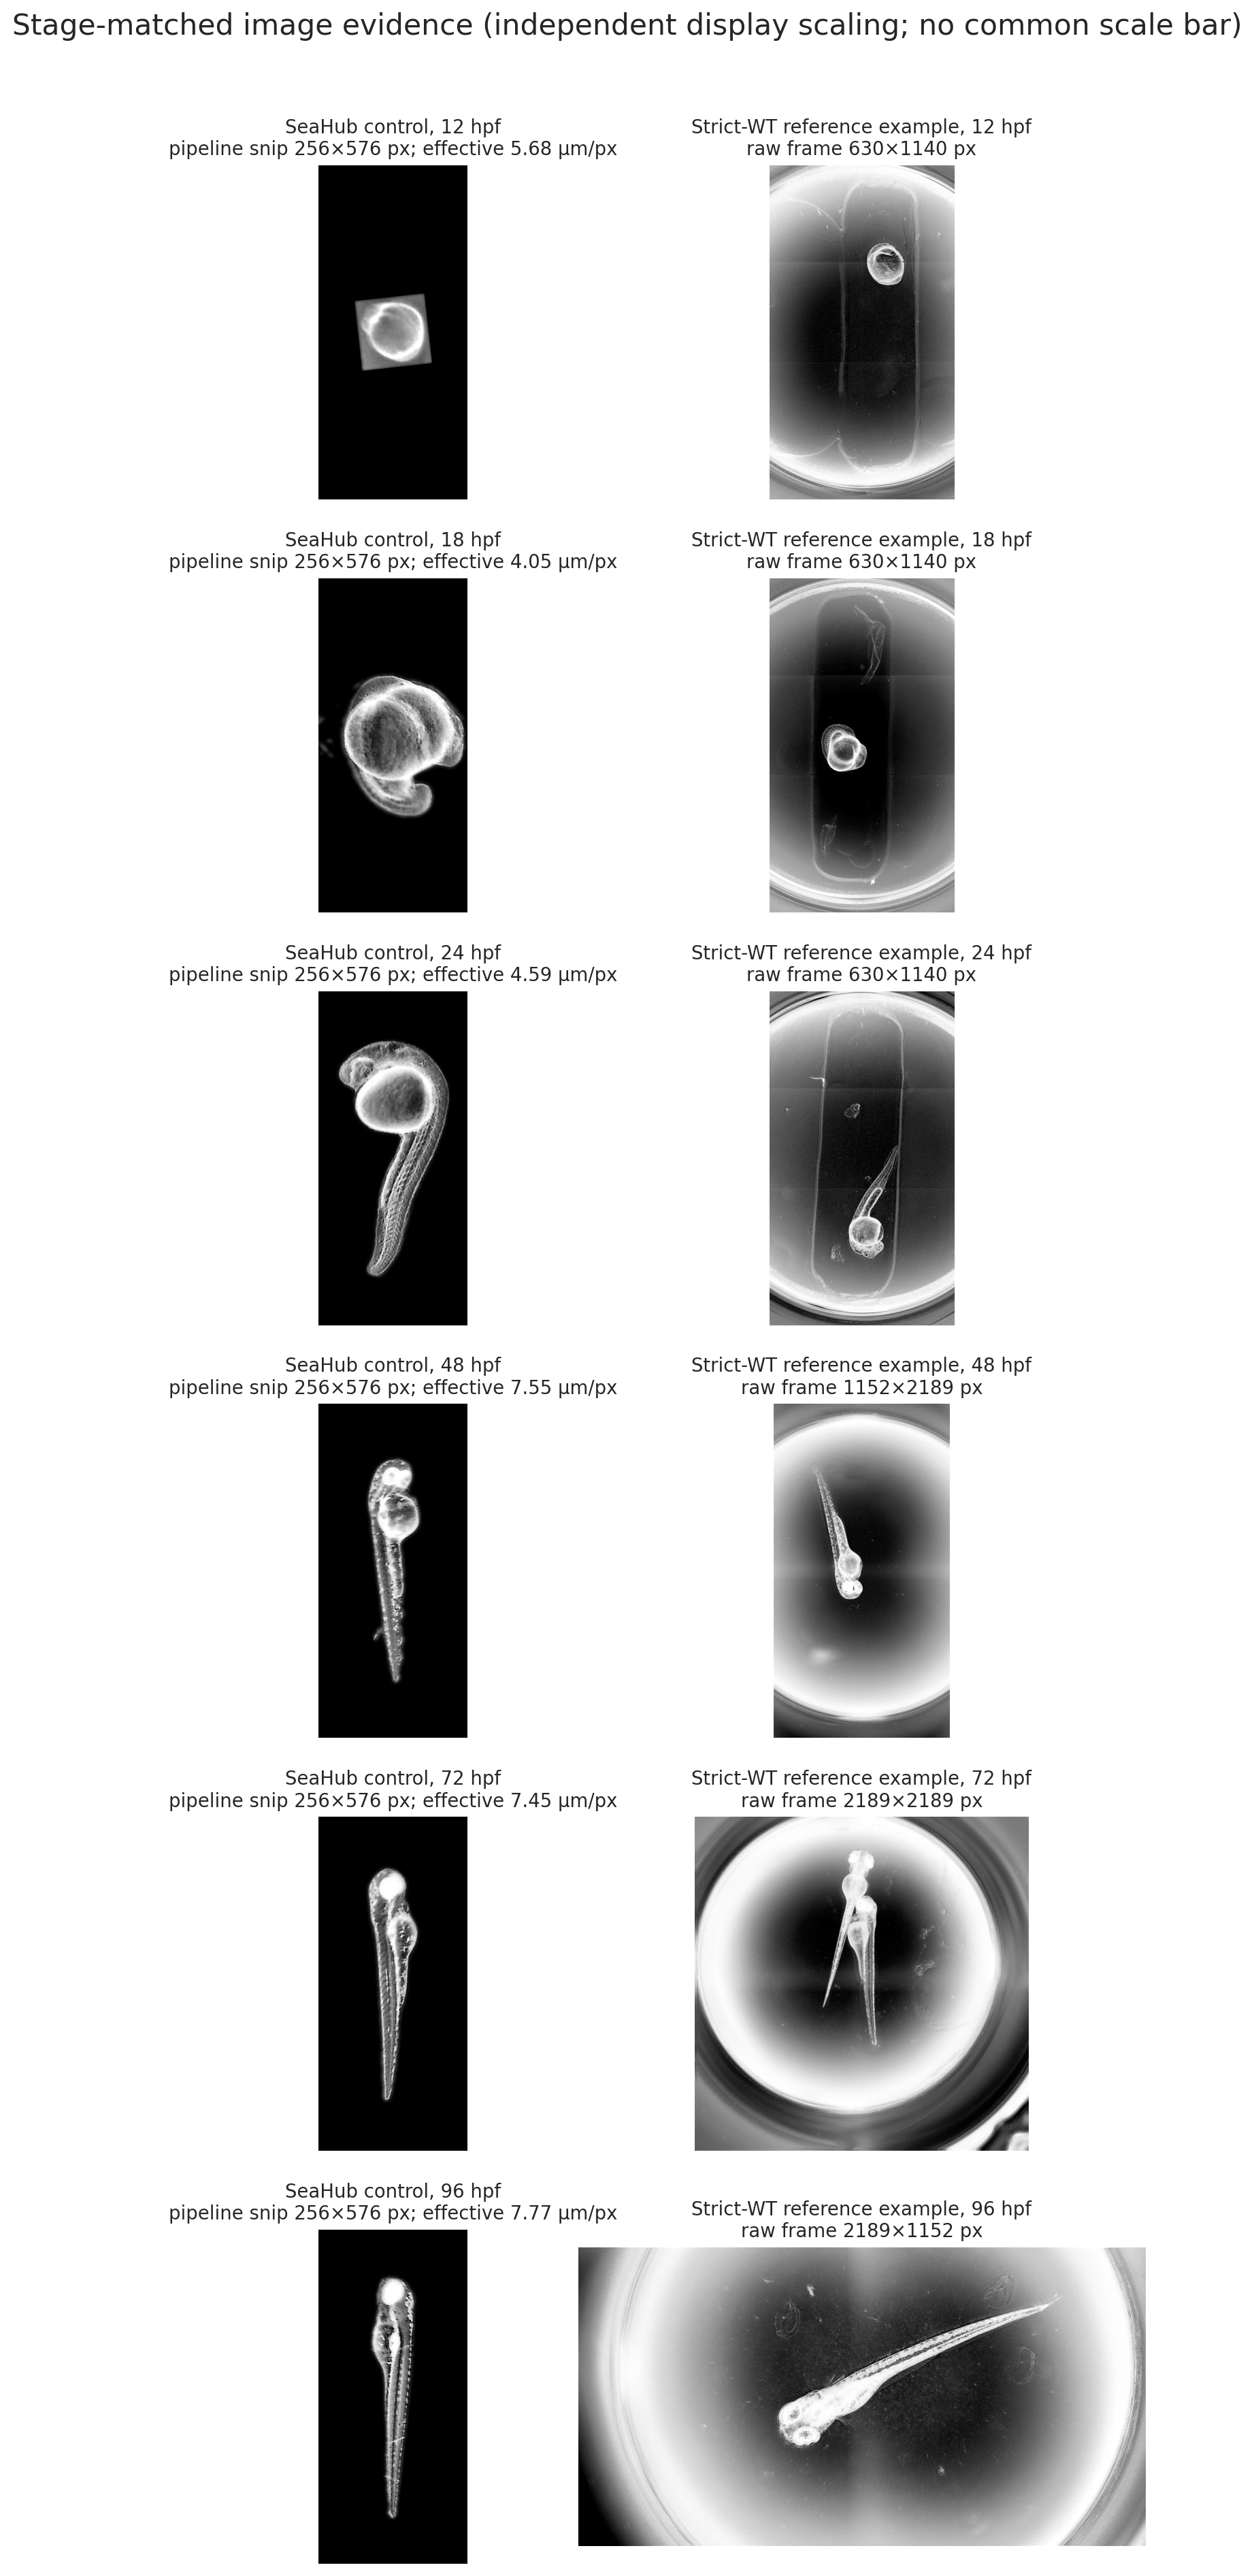

In [5]:
display(Image(filename=str(results["figure_paths"]["image_comparison"])))

## 5. Source-experiment × stage resolution

The source FOV—or, where controls are sparse, source-experiment × stage—is the
most defensible provisional calibration unit. A stage-only lookup averages
over visible FOV-to-FOV variation and should be treated as a fallback.

In [6]:
display(results["experiment_stage_summary"].round(3))

,source_experiment_id,predicted_stage_hpf,n_fovs,n_control_embryos,strict_wt_effective_um_per_px,legacy_curve_effective_um_per_px,fov_min_strict_wt_um_per_px,fov_max_strict_wt_um_per_px
0,CHEM13,72.0,2,16,7.627,8.389,7.292,7.962
1,CHEM13,96.0,3,24,7.776,8.277,7.552,7.994
2,CHEM15,14.0,1,8,4.250,4.363,4.250,4.250
3,CHEM15,18.0,1,8,3.936,3.827,3.936,3.936
4,CHEM15,24.0,1,8,4.630,4.366,4.630,4.630
5,CHEM15,48.0,2,16,6.844,7.211,6.363,7.326
6,CHEM15,72.0,2,16,7.118,7.830,6.766,7.471
7,CHEM15,96.0,2,16,7.702,8.198,7.376,8.027
8,CHEM16,14.0,1,8,5.701,5.852,5.701,5.701
9,CHEM16,24.0,3,24,4.478,4.223,4.320,5.266


## 6. What this means for the current SA QC

The plot below is deliberately an **operational** projection: it calibrates
against the same flawed legacy curve that the present QC rule uses. The active
band is `[0.9 × p5, 1.4 × p95]`. It is not a claim that the resulting pass
rate is biologically correct.

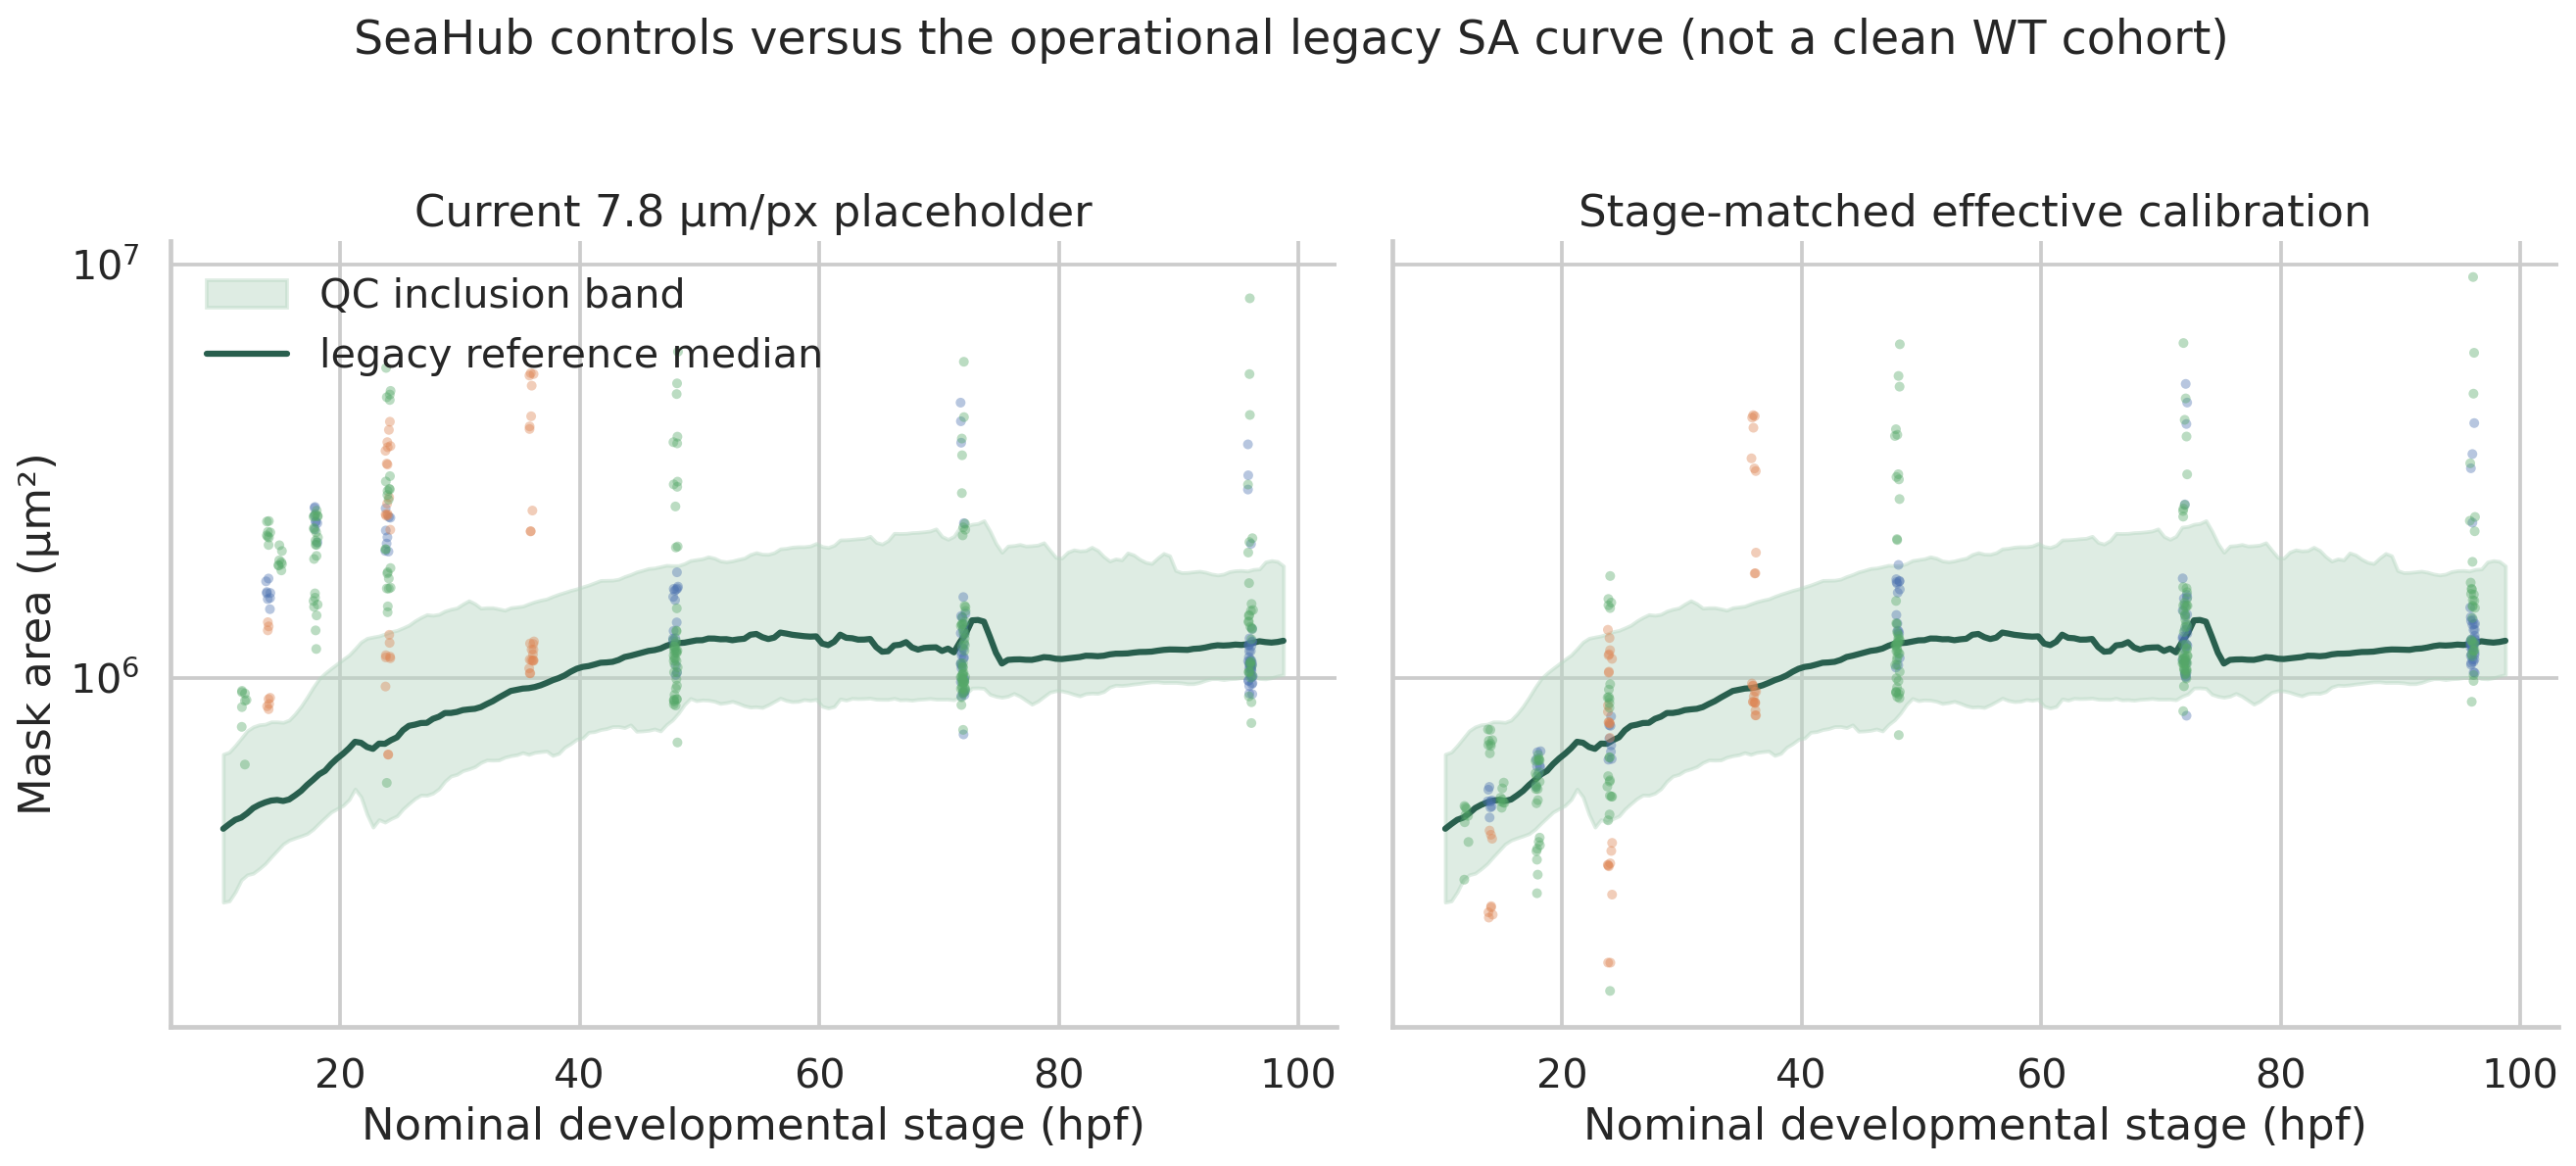

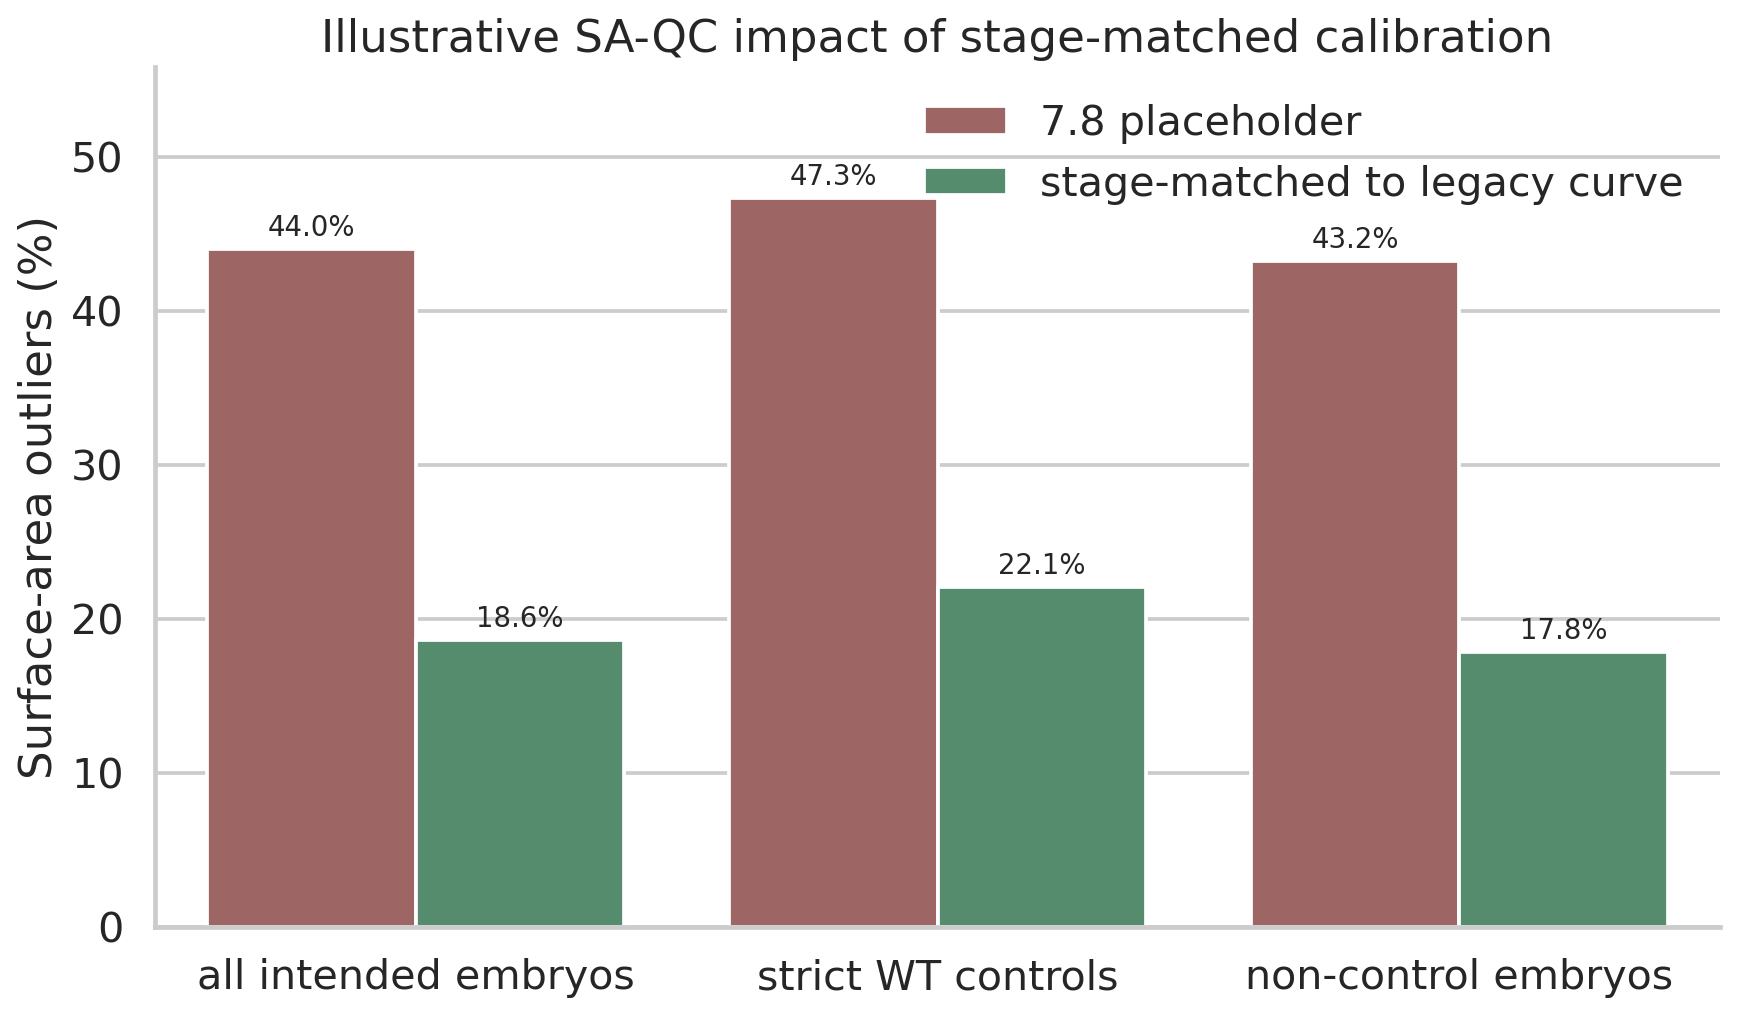

,cohort,calibration,n,n_outlier,outlier_fraction,too_small_fraction,too_large_fraction,outlier_percent
0,all intended embryos,7.8 placeholder,2032,894,0.440,0.049,0.391,43.996
1,all intended embryos,stage-matched to legacy curve,2032,378,0.186,0.084,0.102,18.602
2,strict WT controls,7.8 placeholder,376,178,0.473,0.048,0.426,47.340
3,strict WT controls,stage-matched to legacy curve,376,83,0.221,0.077,0.144,22.074
4,non-control embryos,7.8 placeholder,1656,716,0.432,0.050,0.383,43.237
5,non-control embryos,stage-matched to legacy curve,1656,295,0.178,0.086,0.092,17.814


In [7]:
display(Image(filename=str(results["figure_paths"]["area_comparison"])))
display(Image(filename=str(results["figure_paths"]["qc_projection"])))
display(results["qc_projection"].assign(
    outlier_percent=lambda x: 100*x["outlier_fraction"]
).round(3))

## 7. Sensitivity and limitations

- **Control definition.** The primary SeaHub cohort includes genetic
  `ctrl-inj`, chemical vehicle/untreated controls, and nominal 28C controls.
  Nonstandard 24C/34C controls are excluded from the primary estimate and
  included only in sensitivity tables.
- **Mask multiplicity.** Each SeaHub crop is one intended embryo/well. The
  largest mask per well is primary; `e01` and all-mask alternatives are saved
  below. Largest-vs-e01 has little influence on the headline stage split.
- **QC exclusions.** Surface-area exclusions are not used because that would
  be circular. Death/focus/motion calls are not used because these are
  single-z SeaHub images and those products are known to be annotate-only or
  unreliable in this scope. FOV medians and largest-mask selection provide
  robustness without conditioning on the outcome being calibrated.
- **Biology is not a ruler.** Pose, strain, staging error, segmentation, and
  true biological size all contribute. This is an effective scale estimate,
  not microscope metrology.
- **Sparse late strict-WT reference.** The strict reference has only 21 rows
  at 72 hpf and 5 at 96 hpf. Late estimates remain provisional.
- **Recommended pipeline policy.** Keep physical-size QC annotate-only for
  SeaHub until independent calibration is available. If provisional physical
  features are needed, carry a calibration at source-FOV or
  source-experiment × stage level with explicit provenance; do not replace
  7.8 with one new global constant.

In [8]:
display(
    results["sensitivity"].round(3).style.format({
        "row_weighted_median_um_per_px": "{:.3f}",
        "fov_weighted_median_um_per_px": "{:.3f}",
        "stage_balanced_median_um_per_px": "{:.3f}",
    })
)

,control_cohort,mask_selection,n_rows,n_wells,n_fovs,n_stages,row_weighted_median_um_per_px,fov_weighted_median_um_per_px,stage_balanced_median_um_per_px,row_q25_um_per_px,row_q75_um_per_px
0,chemical vehicle/untreated only,largest mask per intended well,112,112,14,6,7.763,7.936,5.789,4.808000,8.368000
1,chemical vehicle/untreated only,e01 mask per intended well,112,112,14,6,7.763,7.936,5.829,5.030000,8.378000
2,chemical vehicle/untreated only,all masks,140,112,14,6,7.970,8.029,6.647,5.849000,8.591000
3,genetic ctrl-inj only,largest mask per intended well,208,208,26,8,7.131,7.862,5.169,4.349000,8.381000
4,genetic ctrl-inj only,e01 mask per intended well,208,208,26,8,7.131,7.862,5.169,4.349000,8.381000
5,genetic ctrl-inj only,all masks,208,208,26,8,7.131,7.862,5.169,4.349000,8.381000
6,nominal 28C control only,largest mask per intended well,56,56,7,3,5.416,5.852,5.852,3.786000,6.899000
7,nominal 28C control only,e01 mask per intended well,56,56,7,3,6.006,5.975,5.852,4.149000,7.237000
8,nominal 28C control only,all masks,82,56,7,3,6.878,6.986,6.683,4.191000,7.895000
9,strict reference-like controls,largest mask per intended well,376,376,47,9,7.090,7.574,5.658,4.401000,8.255000


## 8. Output inventory

All derived tables and figures are under
`outputs/surface_area_calibration/`. Re-running this notebook regenerates them
from the stable quarantine roots.

In [9]:
for label, path in sorted(results["table_paths"].items()):
    print(f"TABLE  {label:28s} {path}")
for label, path in sorted(results["figure_paths"].items()):
    print(f"FIGURE {label:28s} {path}")

TABLE  all_comparison_rows          /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260723_seahub/outputs/surface_area_calibration/seahub_sa_comparison_rows.csv
TABLE  cohort_audit                 /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260723_seahub/outputs/surface_area_calibration/reference_cohort_audit.csv
TABLE  experiment_stage_summary     /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260723_seahub/outputs/surface_area_calibration/experiment_stage_calibration_summary.csv
TABLE  fov_summary                  /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260723_seahub/outputs/surface_area_calibration/fov_calibration_summary.csv
TABLE  input_manifest               /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260723_seahub/outputs/surface_area_calibration/input_manifest.csv
TABLE  provenance        